In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs

In [2]:
dirs='~/shared/ugit0034/Zhankun/202608/'
diro='~/scratch/ML4O2_temp/'
pfm=['OSD','CTD','PFL']
yr0=[1965,1971,2002]
yr1=[2025,2025,2025]
z1=[137,117,105]
#print(np.round(1.49))
ds=xr.open_dataset(dirs+'Oxygen_OSD_2005.nc')
z=ds['depth'].to_numpy()
np.save('depth.npy',z)
#ds

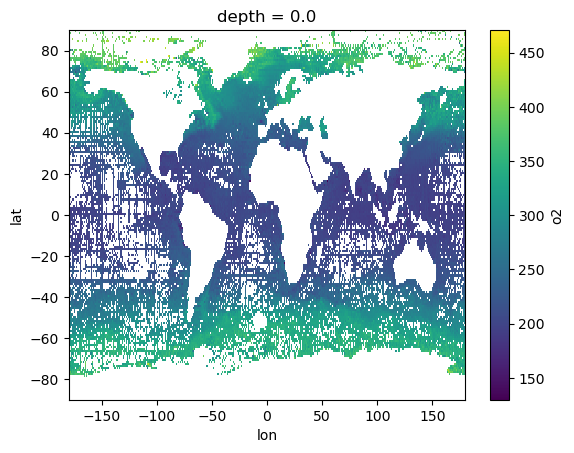

In [5]:
ds=xr.open_dataset(dirs+'Oxygen_NCEI_1x1bin_1965-2025.nc')
ds.o2[:,0,:,:].mean('time').plot()

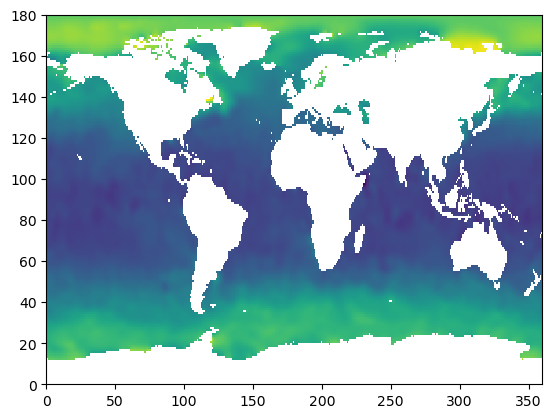

In [6]:
# --------------------------
# WOA2023 all O2 climatology
# --------------------------
o20=np.zeros((102,180,360))
ds0=xr.open_dataset(f'~/shared/ugit0034/woa23/all/oxygen/woa23_all_o00_01.nc',decode_times=False)
o20=ds0.o_an
#
o2=np.zeros((12,102,180,360))
for n in range(12):
    ds0=xr.open_dataset(f'~/shared/ugit0034/woa23/all/oxygen/woa23_all_o{str(n+1).zfill(2)}_01.nc',decode_times=False)
    o2[n,:,:,:]=o20.copy()
    o2[n,:57,:,:]=ds0.o_an
o2woa=o2.copy()
plt.pcolormesh(o2woa[0,0,:,:])

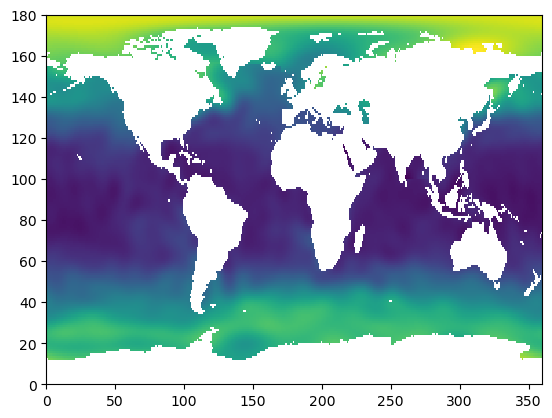

In [12]:
# --------------------------
# Ito22 OI O2 climatology
# --------------------------
o20=np.zeros((102,180,360))
ds0=xr.open_dataset(f'o2_NCEI_ann_clim_65C5.nc')
o20=ds0.o2.roll(lon=180).assign_coords(lon=ds.lon.to_numpy()).to_numpy().astype('float32')
#
o2=np.zeros((12,102,180,360))
ds0=xr.open_dataset(f'o2_NCEI_mon_clim_65C5.nc')
o2[:,:,:,:]=o20.copy()
o2[:,:57,:,:]=ds0.o2.roll(lon=180).assign_coords(lon=ds.lon.to_numpy()).to_numpy().astype('float32')
o2ito=o2.copy()
plt.pcolormesh(o2ito[0,0,:,:])

In [13]:
ds1=ds.isel(depth=slice(0,102))
o2anom=np.zeros_like(ds.o2.to_numpy(),dtype='float32')
for n in range(12):
    o2anom[n::12,:,:,:]=ds1.o2.to_numpy().astype('float32')[n::12,:,:,:]-o2ito[n,:,:,:]
#
da=xr.DataArray(data=o2anom,name='o2anom',dims=['time','depth','lat','lon'],
        coords={'time':ds1.time,'depth':ds1.depth,'lat':ds1.lat,'lon':ds1.lon})
ds2=da.to_dataset()
wn=f'o2anom_NCEI_ItoClim_1x1bin_1965-2025.nc'
ds2.to_netcdf(wn)
ds2

<xarray.Dataset> Size: 19GB
Dimensions:  (time: 732, depth: 102, lat: 180, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1965-01-01 1965-02-01 ... 2025-12-01
  * depth    (depth) float64 816B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    o2anom   (time, depth, lat, lon) float32 19GB nan nan nan ... nan nan nan

In [7]:
ds1=ds.isel(depth=slice(0,102))
o2anom=np.zeros_like(ds.o2.to_numpy(),dtype='float32')
for n in range(12):
    o2anom[n::12,:,:,:]=ds1.o2.to_numpy().astype('float32')[n::12,:,:,:]-o2woa[n,:,:,:]
#
da=xr.DataArray(data=o2anom,name='o2anom',dims=['time','depth','lat','lon'],
        coords={'time':ds1.time,'depth':ds1.depth,'lat':ds1.lat,'lon':ds1.lon})
ds2=da.to_dataset()
wn=f'o2anom_NCEI_WOAClim_1x1bin_1965-2025.nc'
ds2.to_netcdf(wn)
ds2

<xarray.Dataset> Size: 19GB
Dimensions:  (time: 732, depth: 102, lat: 180, lon: 360)
Coordinates:
  * time     (time) datetime64[ns] 6kB 1965-01-01 1965-02-01 ... 2025-12-01
  * depth    (depth) float64 816B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Data variables:
    o2anom   (time, depth, lat, lon) float32 19GB nan nan nan ... nan nan nan